# 01 — Explore data and compute embeddings

This notebook walks through:
1. Loading and inspecting the EAE dataset
2. Checking gene panel overlap with Novae's vocabulary
3. Computing cell embeddings with Novae
4. Assigning spatial domains
5. Aggregating to niche-level representations
6. Comparing niche embeddings across disease stages

**Before running**: `pip install -e .` from the repo root.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "../src")

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Check PyTorch device — M4 Max supports MPS (Metal) acceleration
import torch
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using Apple Silicon GPU via MPS")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")
print(f"PyTorch {torch.__version__}, device: {device}")

Using Apple Silicon GPU via MPS
PyTorch 2.9.1, device: mps


## 1. Load and inspect the data

In [3]:
from temporal_foundation.data import load_adata, build_sample_table, print_coverage

adata = load_adata("/Volumes/processing2/RRmap/data/rrmap.companion.ready.h5ad")

Loading /Volumes/processing2/RRmap/data/rrmap.companion.ready.h5ad...

Loaded 877,141 cells, 5101 genes, 107 samples

In [4]:
sample_table = build_sample_table(adata)
print_coverage(sample_table)

                       MOG coverage                       
┏━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Stage      ┃ Samples ┃ Regions ┃  Cells ┃ Score (mean) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━┩
│ MOG CFA    │       6 │   C,L   │ 35,776 │          0.0 │
│ NONSYMPTOM │       6 │   L,T   │ 30,878 │          0.0 │
│ OS1        │       8 │   L,T   │ 56,541 │          0.5 │
│ PEAK1      │       6 │   L,T   │ 65,703 │          3.0 │
│ LONG       │      10 │   L,T   │ 79,814 │          1.0 │
└────────────┴─────────┴─────────┴────────┴──────────────┘

                       PLP coverage                        
┏━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Stage      ┃ Samples ┃ Regions ┃   Cells ┃ Score (mean) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ PLP CFA    │       9 │  C,L,T  │  59,168 │          0.0 │
│ ONSET1     │       6 │  C,L,T  │  37,087 │          0.2 │
│ ONSET2     │       6 │  C,L,T  │  39,470 │          1.0 │
│ MONOPHASIC │      12 │  C,L,T  │  93,898 │          0.6 │
│ PEAK1      │       9 │  C,L,T  │  91,917 │          2.6 │
│ REMISSION1 │       8 │  C,L,T  │  71,522 │          0.6 │
│ PEAK2      │       9 │  C,L,T  │  83,996 │          2.2 │
│ REMISSION2 │       3 │  C,L,T  │  23,027 │          0.8 │
│ PEAK3      │       9 │  C,L,T  │ 108,344 │          2.8 │
└────────────┴─────────┴─────────┴─────────┴──────────────┘

In [5]:
# Full sample table
sample_table

,sample_id,n_cells,model,stage,course,region,clinical_score,day_of_sacrifice,sex,region_name
0,G6_L2_0,4136,MOG,MOG CFA,MOG CFA,C,0.00,8,F,cervical
1,G6_L3_0,8092,MOG,MOG CFA,MOG CFA,C,0.00,9,M,cervical
2,G6_L3_1,6514,MOG,MOG CFA,MOG CFA,C,0.00,9,M,cervical
3,G4_L1_0,4419,MOG,MOG CFA,MOG CFA,L,0.00,8,F,lumbar
4,G4_L2_2,5998,MOG,MOG CFA,MOG CFA,L,0.00,9,M,lumbar
...,...,...,...,...,...,...,...,...,...,...
102,S2_T1_1,15695,PLP,REMISSION1,remitt I,T,0.75,25,M,thoracic
103,S4_T3_2,6057,PLP,REMISSION1,remitt I,T,0.50,21,F,thoracic
104,S3_T3_1,9180,PLP,REMISSION2,remitt II,C,0.75,48,M,cervical
105,S3_T2_1,7875,PLP,REMISSION2,remitt II,L,0.75,48,M,lumbar


### Quick spatial plot — one sample per disease state

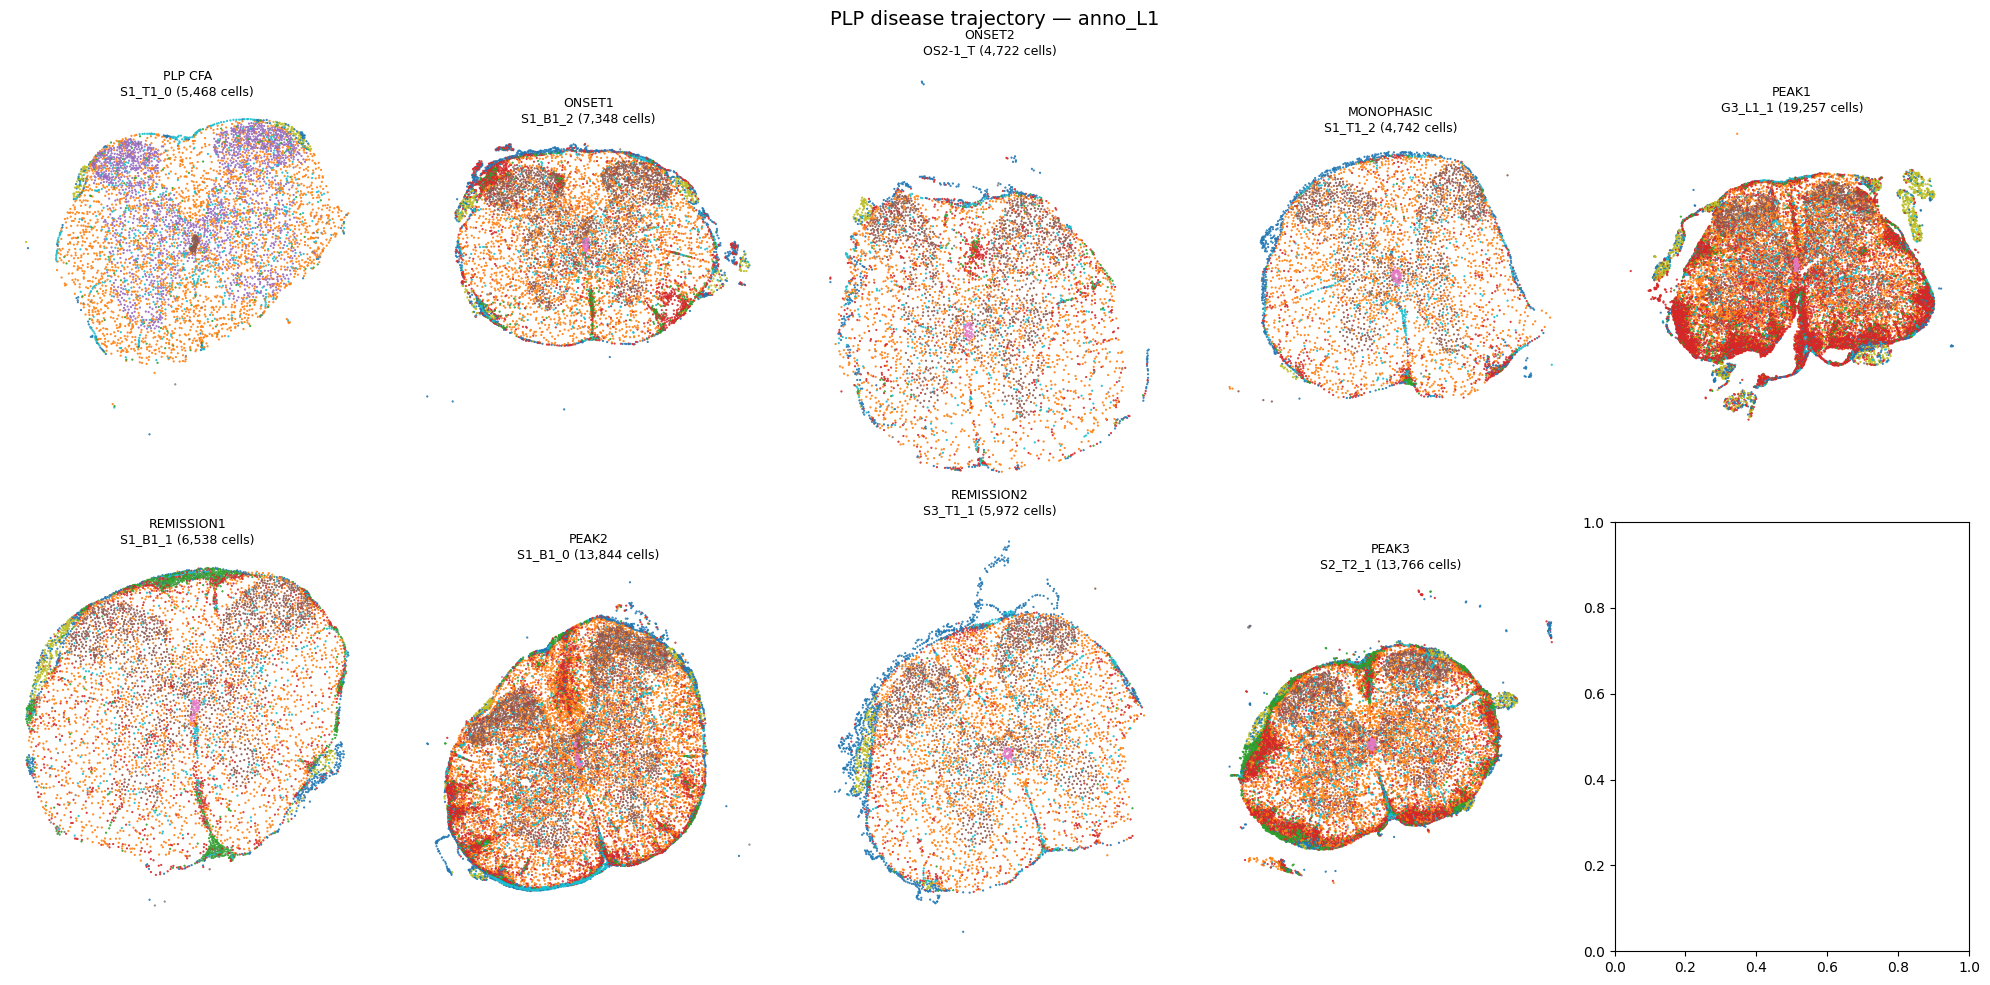

In [6]:
# Pick one sample from each PLP stage to visualize the trajectory
from temporal_foundation.config import MODELS

plp_stages = ["PLP CFA"] + MODELS["PLP"]["stages"]
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for ax, stage in zip(axes.flat, plp_stages[:9]):
    mask = adata.obs["stage"] == stage
    if not mask.any():
        ax.set_title(f"{stage}\n(no data)")
        continue
    
    # Take first sample for this stage
    first_sample = adata.obs.loc[mask, "sample_id"].iloc[0]
    sample_mask = adata.obs["sample_id"] == first_sample
    sub = adata[sample_mask]
    
    coords = sub.obsm["spatial"][:, :2]
    ct = sub.obs["anno_L1"].astype("category").cat.codes
    ax.scatter(coords[:, 0], coords[:, 1], c=ct, s=0.3, cmap="tab10", rasterized=True)
    ax.set_title(f"{stage}\n{first_sample} ({sub.n_obs:,} cells)", fontsize=9)
    ax.set_aspect("equal")
    ax.axis("off")

plt.suptitle("PLP disease trajectory — anno_L1", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Check gene overlap with Novae

Your genes are in mouse format (e.g. `Aatf`, `A2m`). Novae was trained on both
human and mouse data — let's check how many genes it recognizes.

In [7]:
import novae

# List available Novae models
from huggingface_hub import list_models

novae_models = list(list_models(author="MICS-Lab", search="novae"))
print("Available Novae models:")
for m in novae_models:
    print(f"  {m.modelId}")

Available Novae models:
  MICS-Lab/novae-test
  MICS-Lab/novae-human-0
  MICS-Lab/novae-mouse-0
  MICS-Lab/novae-brain-0


In [8]:
# Load model and check gene vocabulary overlap
# Update model_id if a mouse-specific model was found above
MODEL_ID = "MICS-Lab/novae-mouse-0"

model = novae.Novae.from_pretrained(MODEL_ID)

# Check vocabulary — novae lowercases gene names
if hasattr(model, "genes"):
    model_genes_lower = set(g.lower() for g in model.genes)
    our_genes_lower = set(g.lower() for g in adata.var_names)
    
    overlap = our_genes_lower & model_genes_lower
    missing = our_genes_lower - model_genes_lower
    
    print(f"Our panel:        {len(our_genes_lower)} genes")
    print(f"Novae vocabulary: {len(model_genes_lower)} genes")
    print(f"Overlap:          {len(overlap)} ({100*len(overlap)/len(our_genes_lower):.1f}%)")
    print(f"Missing:          {len(missing)} ({100*len(missing)/len(our_genes_lower):.1f}%)")
    
    if len(missing) < 30:
        print(f"\nMissing genes: {sorted(missing)}")
    else:
        print(f"\nFirst 20 missing: {sorted(missing)[:20]}...")
else:
    print("Cannot access model.genes — will check after embedding")

Cannot access model.genes — will check after embedding


## 3. Test embedding on a single sample

Quick test on one sample to check Novae runs correctly with the
long link removal and our spatial coordinates.

In [9]:
# Pick a PEAK1 sample to test
test_sample_id = sample_table[sample_table["stage"] == "PEAK1"]["sample_id"].iloc[0]
test_mask = adata.obs["sample_id"] == test_sample_id
test_adata = adata[test_mask].copy()

print(f"Test sample: {test_sample_id}")
print(f"  Stage:  {test_adata.obs['stage'].iloc[0]}")
print(f"  Course: {test_adata.obs['course'].iloc[0]}")
print(f"  Region: {test_adata.obs['region'].iloc[0]}")
print(f"  Cells:  {test_adata.n_obs:,}")
print(f"  Genes:  {test_adata.n_vars}")

Test sample: G3_L1_1
  Stage:  PEAK1
  Course: chronic peak
  Region: L
  Cells:  19,257
  Genes:  5101


In [10]:
# (autoreload handles module reloading automatically)

In [11]:
from temporal_foundation.embeddings import compute_novae_embeddings
from temporal_foundation.config import EmbeddingConfig

embed_config = EmbeddingConfig(
    novae_model_id=MODEL_ID,
    novae_technology="xenium",
    novae_domain_level=30,
    neighbor_radius=50.0,        # remove edges > 200um
    remove_long_links=True,        # trim top 1% longest edges
    long_link_percentile=99.0,
    batch_correct=False,           # no batch correction for single sample
)

# Check what's in X
print(f"adata.X type: {type(test_adata.X)}")
print(f"adata.X max: {test_adata.X.max():.2f}")
print(f"layers available: {list(test_adata.layers.keys())}")

compute_novae_embeddings(test_adata, embed_config)

adata.X type: <class 'scipy.sparse._csr.csr_matrix'>
adata.X max: 8.53
layers available: ['counts', 'normalized']


Building spatial graph (using existing coordinates)...

[INFO] (novae.utils.build) Computing graph on 19,257 cells (coord_type=generic, delaunay=True, radius=[0.0, 50.0], n_neighs=None)


Removed long links: 1132 edges removed (threshold=43.6um, percentile=99.0)

Loading Novae model: MICS-Lab/novae-mouse-0

...

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Computing representations:   0%|          | 0/38 [00:00<?, ?it/s]

Assigning spatial domains (level=30)...

Done: 64d embeddings, 30 spatial domains

AnnData object with n_obs × n_vars = 19257 × 5101
    obs: 'cell', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'sample_id', 'proseg_cluster', 'output_folder', 'Num', 'n_genes', 'n_counts', 'louvain_0.5', 'louvain_1', 'louvain_1.5', 'louvain_2', 'louvain_2.5', 'louvain_3', 'louvain_3.5', 'Cluster', 'Level1', 'Level2', 'Level3', 'Level3.1', 'grid_label', 'rbd_domain', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.3', 'rbd_domain_0.5', 'rbd_domain_0.6', 'rbd_domain_0.7', 'rbd_domain_0.8', 'rbd_domain_0.9', 'rbd_domain_1.1', 'rbd_domain_1', 'rbd_domain_1.25', 'rbd_domain_1.4', 'rbd_domain_1.5', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'sample_name', 'course', 'condition', 'model', 'cytetype_annotation_louvain_3.5', 'cytetype_cellOntologyTerm_louvain_3.5', 'cluster_id', 'author_label', 'annotation', 'Class', 'state', 'CL_term', 'CL_term_id', 'confidence', 'author_label_similarity_s

In [12]:
test_adata.obs

,cell,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,sample_id,...,stage,day_of_sacrifice,score_sacrifice,sex,k_means_name,novae_sid,neighborhood_valid,novae_leaves,novae_domains_30,novae_domains
cell_id,,,,,,,,,,,,,,,,,,,,,
npbjhhhp-1,0,3926.366699,791.557556,0.131098,2,10.25,80.0,1.0,L,G3_L1_1,...,PEAK1,16,3.0,M,G3_L1_1,34029424368,False,NaN,NaN,NaN
ekkkkjhg-1,1,4213.269531,626.309937,0.125000,7,21.50,110.0,1.0,L,G3_L1_1,...,PEAK1,16,3.0,M,G3_L1_1,34029424368,False,NaN,NaN,NaN
ekmlkkdo-1,2,4252.181152,650.484375,0.258333,1,3.75,74.0,1.0,L,G3_L1_1,...,PEAK1,16,3.0,M,G3_L1_1,34029424368,True,D482,D991,D991
ekmkkhfi-1,3,4253.136719,656.426514,0.279959,7,30.25,178.0,1.0,L,G3_L1_1,...,PEAK1,16,3.0,M,G3_L1_1,34029424368,True,D353,D991,D991
ekkgfobi-1,4,4268.301270,639.604370,0.261667,4,18.75,142.0,1.0,L,G3_L1_1,...,PEAK1,16,3.0,M,G3_L1_1,34029424368,True,D482,D991,D991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hblfbejn-1,20322,5731.493164,3132.653809,0.875000,7,14.75,94.0,1.0,L,G3_L1_1,...,PEAK1,16,3.0,M,G3_L1_1,34029424368,True,D114,D991,D991
jefgkoab-1,20323,5902.111816,3521.750488,0.875000,1,35.75,156.0,1.0,L,G3_L1_1,...,PEAK1,16,3.0,M,G3_L1_1,34029424368,True,D422,D980,D980
jefdeenc-1,20324,5892.022461,3530.870117,0.875000,1,48.50,170.0,1.0,L,G3_L1_1,...,PEAK1,16,3.0,M,G3_L1_1,34029424368,False,NaN,NaN,NaN


In [13]:
embed_config

EmbeddingConfig(encoder='novae', novae_model_id='MICS-Lab/novae-mouse-0', novae_technology='xenium', novae_domain_level=30, neighbor_radius=50.0, remove_long_links=True, long_link_percentile=99.0, accelerator='cpu', num_workers=0, batch_correct=False, latent_key='novae_latent', domain_key='novae_domains')

In [14]:
adata

AnnData object with n_obs × n_vars = 877141 × 5101
    obs: 'cell', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'sample_id', 'proseg_cluster', 'output_folder', 'Num', 'n_genes', 'n_counts', 'louvain_0.5', 'louvain_1', 'louvain_1.5', 'louvain_2', 'louvain_2.5', 'louvain_3', 'louvain_3.5', 'Cluster', 'Level1', 'Level2', 'Level3', 'Level3.1', 'grid_label', 'rbd_domain', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.3', 'rbd_domain_0.5', 'rbd_domain_0.6', 'rbd_domain_0.7', 'rbd_domain_0.8', 'rbd_domain_0.9', 'rbd_domain_1.1', 'rbd_domain_1', 'rbd_domain_1.25', 'rbd_domain_1.4', 'rbd_domain_1.5', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'sample_name', 'course', 'condition', 'model', 'cytetype_annotation_louvain_3.5', 'cytetype_cellOntologyTerm_louvain_3.5', 'cluster_id', 'author_label', 'annotation', 'Class', 'state', 'CL_term', 'CL_term_id', 'confidence', 'author_label_similarity_

In [15]:
test_adata.obs.cluster_cellcharter_15

cell_id
npbjhhhp-1    8
ekkkkjhg-1    1
ekmlkkdo-1    1
ekmkkhfi-1    1
ekkgfobi-1    1
             ..
hblfbejn-1    1
jefgkoab-1    1
jefdeenc-1    8
jefejjba-1    8
jefjcboj-1    1
Name: cluster_cellcharter_15, Length: 19257, dtype: category
Categories (14, object): ['0', '1', '2', '3', ..., '11', '12', '13', '14']

/Users/christoffer/miniconda3/envs/novae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


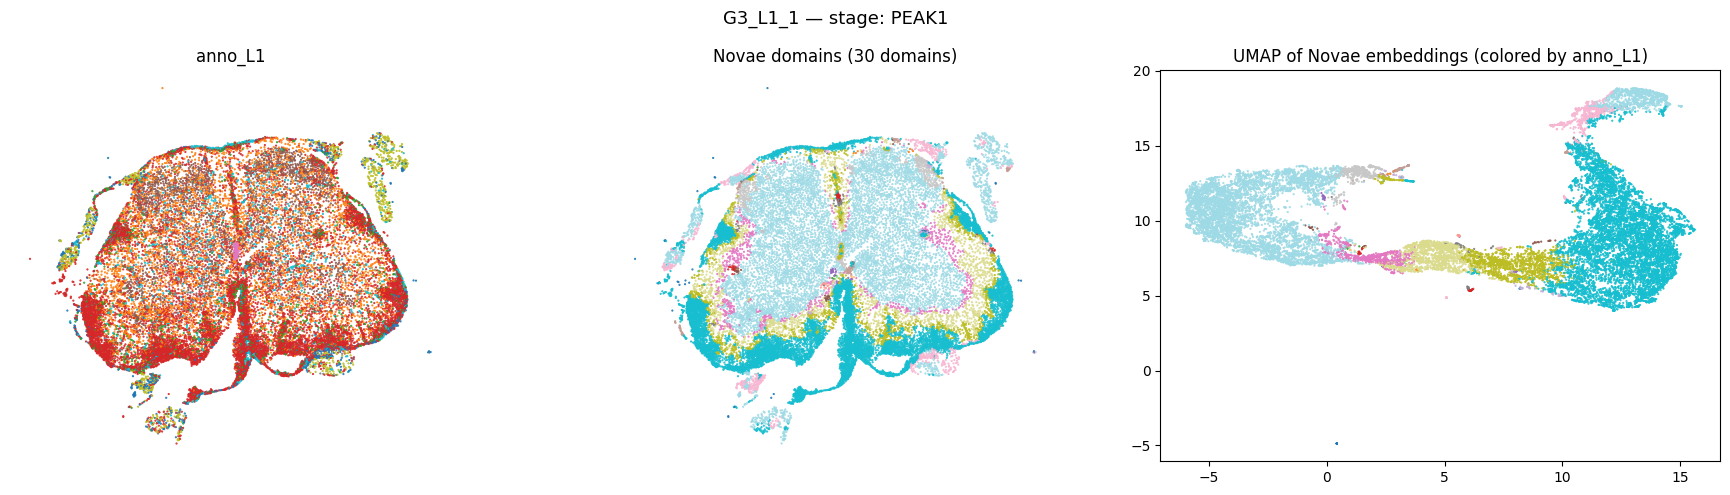

In [16]:
# Visualize the result
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
coords = test_adata.obsm["spatial"][:, :2]

# Cell types
ct = test_adata.obs["anno_L1"].astype("category").cat.codes
axes[0].scatter(coords[:, 0], coords[:, 1], c=ct, s=0.3, cmap="tab10", rasterized=True)
axes[0].set_title("anno_L1")
axes[0].set_aspect("equal")
axes[0].axis("off")

# Novae spatial domains
if embed_config.domain_key in test_adata.obs.columns:
    domains = test_adata.obs[embed_config.domain_key].astype("category").cat.codes
    axes[1].scatter(coords[:, 0], coords[:, 1], c=domains, s=0.3, cmap="tab20", rasterized=True)
    axes[1].set_title(f"Novae domains ({test_adata.obs[embed_config.domain_key].nunique()} domains)")
    axes[1].set_aspect("equal")
    axes[1].axis("off")

# UMAP of Novae embeddings
if embed_config.latent_key in test_adata.obsm:
    from sklearn.decomposition import PCA
    import umap

    latent = test_adata.obsm[embed_config.latent_key]
    if latent.shape[1] > 50:
        latent = PCA(n_components=50).fit_transform(latent)

    coords_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(latent)
    axes[2].scatter(coords_umap[:, 0], coords_umap[:, 1], c=domains, s=0.3, cmap="tab20", rasterized=True)
    axes[2].set_title("UMAP of Novae embeddings (colored by anno_L1)")

plt.suptitle(f"{test_sample_id} — stage: {test_adata.obs['stage'].iloc[0]}", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Embed all samples

Process each sample individually. Fast (~few minutes total) and the
niche embeddings are identical to combined processing. Batch correction
can be applied post-hoc if needed.

In [17]:
embed_config

EmbeddingConfig(encoder='novae', novae_model_id='MICS-Lab/novae-mouse-0', novae_technology='xenium', novae_domain_level=30, neighbor_radius=50.0, remove_long_links=True, long_link_percentile=99.0, accelerator='cpu', num_workers=0, batch_correct=False, latent_key='novae_latent', domain_key='novae_domains')

In [ ]:
from temporal_foundation.data import split_by_sample
from temporal_foundation.embeddings import compute_novae_batch, save_embeddings

OUTPUT_DIR = Path("../data/embedded")

embed_config.batch_correct = False  # only works with combined processing

# Split into individual samples
samples = split_by_sample(adata)

# Embed each sample individually

samples = compute_novae_batch(samples, embed_config)

# Save to disk
save_embeddings(samples, OUTPUT_DIR, embed_config)

## 5. Load embedded samples and aggregate to niches

Load the saved per-sample embeddings from disk, check the Novae output keys,
then aggregate to niche-level representations.

In [ ]:
from temporal_foundation.embeddings import load_embeddings
from temporal_foundation.aggregation import aggregate_all_samples, summarize_representations
from temporal_foundation.config import AggregationConfig

# Load embedded samples from disk
samples = load_embeddings(OUTPUT_DIR, embed_config)

# Check what keys Novae added
s = next(iter(samples.values()))
print("obsm keys:", list(s.obsm.keys()))
print("novae obs columns:", [c for c in s.obs.columns if 'novae' in c.lower()])

# Use the correct latent key
latent_key = embed_config.latent_key
if latent_key not in s.obsm:
    # Novae may use a different key — find it
    novae_keys = [k for k in s.obsm.keys() if 'novae' in k.lower()]
    if novae_keys:
        latent_key = novae_keys[0]
        print(f"Using detected key: {latent_key}")

# Find domain key
domain_key = embed_config.domain_key
if domain_key not in s.obs.columns:
    novae_cols = [c for c in s.obs.columns if 'novae' in c.lower()]
    if novae_cols:
        domain_key = novae_cols[0]
        print(f"Using detected domain key: {domain_key}")

print(f"\nLatent key: {latent_key} (shape: {s.obsm[latent_key].shape})")
print(f"Domain key: {domain_key} ({s.obs[domain_key].nunique()} domains)")

agg_config = AggregationConfig(
    method="spatial_domains",
    domain_key=domain_key,
    embedding_key=latent_key,
    include_composition=True,
    cell_type_key="anno_L2",
)

representations = aggregate_all_samples(samples, agg_config)
summary = summarize_representations(representations)
summary

Loaded 107 embedded samples

obsm keys: ['X_karo_comp', 'X_mana_gauss', 'X_mana_gauss_2neigh', 'X_pca', 'X_scVI', 'X_umap', 'novae_latent', 'spatial']
novae obs columns: ['novae_sid', 'novae_leaves', 'novae_domains_10', 'novae_domains']

Latent key: novae_latent (shape: (10909, 64))
Domain key: novae_domains (10 domains)


Aggregated 107 samples

Total niches: 1070 (avg 10 per sample)

,sample_id,model,stage,region,n_niches,total_cells,mean_cells_per_niche,embedding_dim,clinical_score
0,G3_L1_0,MOG,OS1,L,10,10882,1088.2,64,0.50
1,G3_L1_1,MOG,PEAK1,L,10,19237,1923.7,64,3.00
2,G3_L1_2,MOG,NONSYMPTOM,L,10,7367,736.7,64,0.00
3,G3_L2_0,MOG,OS1,L,10,9712,971.2,64,0.50
4,G3_L2_1,MOG,PEAK1,L,10,11636,1163.6,64,3.00
...,...,...,...,...,...,...,...,...,...
102,S4_T2_1,PLP,REMISSION1,C,10,11423,1142.3,64,0.50
103,S4_T2_2,PLP,PEAK2,L,10,8096,809.6,64,2.75
104,S4_T3_0,PLP,PEAK2,C,10,9918,991.8,64,2.75
105,S4_T3_1,PLP,REMISSION1,L,10,6414,641.4,64,0.50


## 6. Compare niche embeddings across disease stages

Pool all niche-level embeddings and visualize how disease stages separate
in embedding space.

In [ ]:
import umap
from sklearn.decomposition import PCA

# Pool all niche embeddings
all_embeddings = np.vstack([r.embeddings for r in representations])
all_stages = np.concatenate([[r.stage] * r.n_niches for r in representations])
all_models = np.concatenate([[r.model] * r.n_niches for r in representations])
all_regions = np.concatenate([[r.region] * r.n_niches for r in representations])

print(f"Total niches: {len(all_stages)}")
print(f"Embedding dim: {all_embeddings.shape[1]}")

# Reduce and project
if all_embeddings.shape[1] > 50:
    emb_pca = PCA(n_components=50).fit_transform(all_embeddings)
else:
    emb_pca = all_embeddings

coords_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(emb_pca)

Total niches: 1070
Embedding dim: 64


/Users/christoffer/miniconda3/envs/novae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


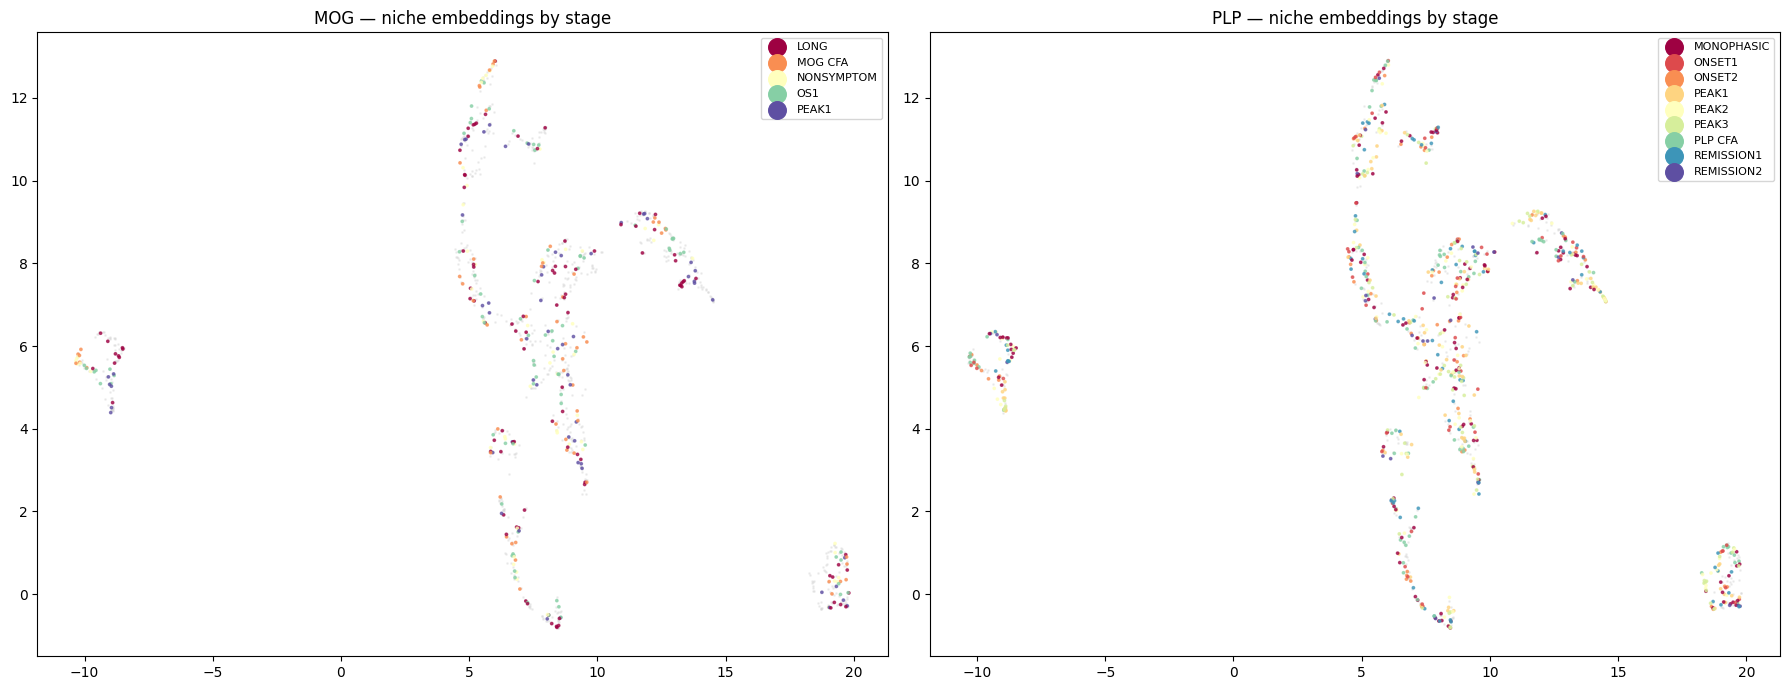

In [ ]:
# Plot: MOG vs PLP, colored by disease stage
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model_name in zip(axes, ["MOG", "PLP"]):
    mask = all_models == model_name
    if not mask.any():
        ax.set_title(f"{model_name} — no data")
        continue
    
    # Plot background (other model) in grey
    other_mask = ~mask
    ax.scatter(coords_umap[other_mask, 0], coords_umap[other_mask, 1],
               c="lightgrey", s=1, alpha=0.3, rasterized=True)
    
    # Plot this model colored by stage
    stages_here = pd.Categorical(all_stages[mask])
    scatter = ax.scatter(
        coords_umap[mask, 0], coords_umap[mask, 1],
        c=stages_here.codes, s=3, cmap="Spectral", alpha=0.7, rasterized=True
    )
    ax.set_title(f"{model_name} — niche embeddings by stage")
    
    # Legend
    unique_stages = stages_here.categories
    n = len(unique_stages)
    handles = [plt.scatter([], [], c=[plt.cm.Spectral(i / max(n-1, 1))], s=40)
               for i in range(n)]
    ax.legend(handles, unique_stages, loc="best", fontsize=8, markerscale=2,
              framealpha=0.8)

plt.tight_layout()
plt.show()

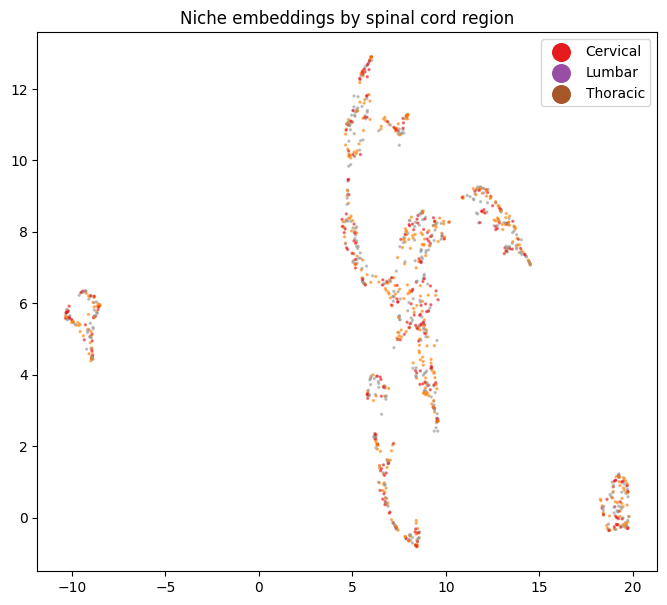

In [ ]:
# Also color by spinal cord region — check if spatial location drives more
# variance than disease state
fig, ax = plt.subplots(figsize=(8, 7))
region_map = {"C": 0, "L": 1, "T": 2}
region_colors = [region_map[r] for r in all_regions]
ax.scatter(coords_umap[:, 0], coords_umap[:, 1], c=region_colors, s=2,
           cmap="Set1", alpha=0.5, rasterized=True)
handles = [plt.scatter([], [], c=[plt.cm.Set1(i/3)], s=40) for i in range(3)]
ax.legend(handles, ["Cervical", "Lumbar", "Thoracic"], fontsize=10, markerscale=2)
ax.set_title("Niche embeddings by spinal cord region")
plt.show()

### Key transition comparisons

Cosine distances between mean niche embeddings at key disease stages.

In [ ]:
from scipy.spatial.distance import cosine
from temporal_foundation.config import get_transition_pairs, SHARED_STAGES

# Compute mean niche embedding per (model, stage)
stage_means = {}
for r in representations:
    key = (r.model, r.stage)
    if key not in stage_means:
        stage_means[key] = []
    stage_means[key].append(r.embeddings.mean(axis=0))

for key in stage_means:
    stage_means[key] = np.mean(stage_means[key], axis=0)

# Print transition distances for each model
for model_name in ["MOG", "PLP"]:
    print(f"\n{model_name} consecutive transitions:")
    pairs = get_transition_pairs(model_name)
    for from_s, to_s in pairs:
        k1, k2 = (model_name, from_s), (model_name, to_s)
        if k1 in stage_means and k2 in stage_means:
            dist = cosine(stage_means[k1], stage_means[k2])
            print(f"  {from_s:15s} -> {to_s:15s}  cosine dist = {dist:.4f}")

# Cross-model comparison at shared stages
print(f"\nCross-model comparison at shared stages: {SHARED_STAGES}")
for stage in SHARED_STAGES:
    k_mog, k_plp = ("MOG", stage), ("PLP", stage)
    if k_mog in stage_means and k_plp in stage_means:
        dist = cosine(stage_means[k_mog], stage_means[k_plp])
        print(f"  MOG {stage} <-> PLP {stage}  dist={dist:.4f}")
        print(f"  (Both at {stage} but MOG goes chronic, PLP goes to remission)")

# PLP internal comparisons
print("\nPLP peak-to-peak comparisons (are relapses similar?):")
plp_peaks = ["PEAK1", "PEAK2", "PEAK3"]
for i, p1 in enumerate(plp_peaks):
    for p2 in plp_peaks[i+1:]:
        k1, k2 = ("PLP", p1), ("PLP", p2)
        if k1 in stage_means and k2 in stage_means:
            dist = cosine(stage_means[k1], stage_means[k2])
            print(f"  {p1} <-> {p2}  dist={dist:.4f}")

print("\nPLP remission comparisons:")
k1, k2 = ("PLP", "REMISSION1"), ("PLP", "REMISSION2")
if k1 in stage_means and k2 in stage_means:
    dist = cosine(stage_means[k1], stage_means[k2])
    print(f"  REMISSION1 <-> REMISSION2  dist={dist:.4f}")


MOG consecutive transitions:
  MOG CFA         -> NONSYMPTOM       cosine dist = 0.0179
  NONSYMPTOM      -> OS1              cosine dist = 0.0443
  OS1             -> PEAK1            cosine dist = 0.0225
  PEAK1           -> LONG             cosine dist = 0.0215

PLP consecutive transitions:
  PLP CFA         -> ONSET1           cosine dist = 0.0196
  ONSET1          -> ONSET2           cosine dist = 0.0197
  ONSET2          -> MONOPHASIC       cosine dist = 0.0230
  MONOPHASIC      -> PEAK1            cosine dist = 0.0333
  PEAK1           -> REMISSION1       cosine dist = 0.0451
  REMISSION1      -> PEAK2            cosine dist = 0.0084
  PEAK2           -> REMISSION2       cosine dist = 0.0201
  REMISSION2      -> PEAK3            cosine dist = 0.0375

Cross-model comparison at shared stages: {'PEAK1'}
  MOG PEAK1 <-> PLP PEAK1  dist=0.0221
  (Both at PEAK1 but MOG goes chronic, PLP goes to remission)

PLP peak-to-peak comparisons (are relapses similar?):
  PEAK1 <-> PEAK2  dist=

: 

## 7. Embed full dataset combined

Re-embed all 877k cells together (not per-sample) so that:
- **Spatial domains are consistent** across all 107 samples (same domain ID = same niche type)
- **Batch correction** via Novae's optimal transport is applied across samples
- **Embeddings are directly comparable** without post-hoc alignment

This takes longer than per-sample embedding (~15-30 min on CPU) but produces
better representations for downstream transition analysis.


In [21]:
from temporal_foundation.embeddings import compute_novae_embeddings_combined, save_embedded
from temporal_foundation.config import EmbeddingConfig

combined_config = EmbeddingConfig(
    novae_model_id=MODEL_ID,
    novae_technology="xenium",
    novae_domain_level=30,
    neighbor_radius=75.0,
    remove_long_links=True,
    long_link_percentile=99.0,
    accelerator="cpu",       # change to "mps" for Apple Silicon GPU
    num_workers=0,
    batch_correct=True,       # key difference from per-sample embedding
)

print(f"Config: {combined_config}")
print(f"Cells to embed: {adata.n_obs:,}")
print(f"Samples: {adata.obs['sample_id'].nunique()}")


Config: EmbeddingConfig(encoder='novae', novae_model_id='MICS-Lab/novae-mouse-0', novae_technology='xenium', novae_domain_level=30, neighbor_radius=75.0, remove_long_links=True, long_link_percentile=99.0, accelerator='cpu', num_workers=0, batch_correct=True, latent_key='novae_latent', domain_key='novae_domains')
Cells to embed: 877,141
Samples: 107


In [ ]:
import time

t0 = time.time()
adata = compute_novae_embeddings_combined(adata, combined_config)
elapsed = time.time() - t0
print(f"\nEmbedding took {elapsed / 60:.1f} minutes")


Building spatial graph (using existing coordinates)...

[INFO] (novae.utils.build) Computing graph on 877,141 cells (coord_type=generic, delaunay=True, radius=[0.0, 75.0], n_neighs=None)


Removed long links: 51942 edges removed (threshold=59.5um, percentile=99.0)

Loading Novae model: MICS-Lab/novae-mouse-0

Computing cell embeddings (877,141 cells, accelerator=cpu)...

Computing representations:   0%|          | 0/1712 [00:00<?, ?it/s]

In [ ]:
# Inspect the results
print(f"obsm keys: {list(adata.obsm.keys())}")
novae_obs = [c for c in adata.obs.columns if 'novae' in c.lower()]
print(f"novae obs columns: {novae_obs}")

if 'novae_domains' in adata.obs.columns:
    print(f"Domains: {adata.obs['novae_domains'].nunique()}")
    print(f"\nDomain distribution (top 10):")
    print(adata.obs['novae_domains'].value_counts().head(10))

latent_key = 'novae_latent_corrected' if 'novae_latent_corrected' in adata.obsm else 'novae_latent'
print(f"\nUsing latent key: {latent_key} (dim={adata.obsm[latent_key].shape[1]})")


In [ ]:
# Save the combined embedded dataset
OUTPUT_COMBINED = Path("../data/embedded_combined.h5ad")
save_embedded(adata, OUTPUT_COMBINED)
print(f"Saved to {OUTPUT_COMBINED}")


In [ ]:
# Quick comparison: per-sample vs combined domains for one sample
test_sid = sample_table[sample_table['stage'] == 'PEAK1']['sample_id'].iloc[0]
test_mask = adata.obs['sample_id'] == test_sid
test_sub = adata[test_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
coords = test_sub.obsm['spatial'][:, :2]

# Combined domains
domains = test_sub.obs['novae_domains'].astype('category').cat.codes
axes[0].scatter(coords[:, 0], coords[:, 1], c=domains, s=0.3, cmap='tab20', rasterized=True)
axes[0].set_title(f'{test_sid} — combined domains ({test_sub.obs["novae_domains"].nunique()})')
axes[0].set_aspect('equal')

# Batch-corrected embedding UMAP (all samples)
import umap
latent_key = 'novae_latent_corrected' if 'novae_latent_corrected' in adata.obsm else 'novae_latent'

# Subsample for UMAP speed
n_sub = min(50_000, adata.n_obs)
idx = np.random.choice(adata.n_obs, n_sub, replace=False)
emb_sub = adata.obsm[latent_key][idx]
stages_sub = adata.obs[STAGE_KEY].values[idx]
models_sub = adata.obs[MODEL_KEY].values[idx]

reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
coords_umap = reducer.fit_transform(emb_sub)

# Color by stage
from temporal_foundation.config import model_short_name
stage_list = sorted(set(stages_sub))
stage_to_int = {s: i for i, s in enumerate(stage_list)}
stage_colors = [stage_to_int[s] for s in stages_sub]

sc = axes[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c=stage_colors,
                     s=0.5, cmap='tab20', alpha=0.5, rasterized=True)
axes[1].set_title(f'Combined UMAP ({n_sub:,} cells, colored by stage)')

plt.tight_layout()
plt.show()

# Legend
fig, ax = plt.subplots(figsize=(4, 4))
for stage, idx_val in sorted(stage_to_int.items(), key=lambda x: x[1]):
    ax.scatter([], [], c=[plt.cm.tab20(idx_val / len(stage_list))], label=stage, s=30)
ax.legend(fontsize=7, ncol=2)
ax.set_axis_off()
ax.set_title('Stage legend')
plt.tight_layout()
plt.show()


## Next steps

What to look for in the results above:

1. **Gene overlap** — if < 50%, the embeddings may not be meaningful and we should
   look into gene name mapping (mouse -> human) or a different model.
2. **UMAP stage separation** — if stages form distinct clusters, Novae captures
   disease-relevant spatial signal. If it clusters mainly by region (C/L/T), the
   spatial structure dominates and we may need to model region as a covariate.
3. **PEAK1 cross-model comparison** — both MOG and PLP have PEAK1 samples. If they
   occupy the same embedding space, the spatial state is similar despite divergent
   outcomes. Differences would point to what drives remission vs. chronicity.
4. **Transition distances** — larger cosine distance = bigger spatial reorganization.
   Compare PEAK->REMISSION distances across PLP cycles.

Once this looks good, proceed to `02_transition_model.ipynb` to build the
temporal model on the niche representations.